<a href="https://colab.research.google.com/github/MarilynMaika/NLP_REPO/blob/main/Attention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Attention Mechanism
<ul> <li>This notebook explores attention mechanisms and Transformers in NLP tasks. <li>The exercise uses a simplified Transformer model for a text classification task, demonstrating the attention mechanism's role in understanding contextual relationships. <li> It includes visualization of attention weights to illustrate how the model focuses on different parts of the input. </ul>
TASKS:
<ol>
<li>Implement a custom Multi-Head Attention layer to demonstrate the attention mechanism.
<li>Build a Transformer encoder layer with attention and feed-forward components.
<li>Use a small sentiment analysis dataset to train a Transformer model.
<li>Visualize attention weights to show how the model focuses on different words.
<li>Make predictions on new text to demonstrate practical use.

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Layer, Input, Embedding, Dense, LayerNormalization
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# 1. Defining the Multi-Head Attention Layer
class MultiHeadAttention(Layer):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model
        assert d_model % num_heads == 0
        self.depth = d_model // num_heads
        self.Wq = Dense(d_model)
        self.Wk = Dense(d_model)
        self.Wv = Dense(d_model)
        self.dense = Dense(d_model)

    def split_heads(self, x, batch_size):
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.depth))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def call(self, query, key, value, mask=None):
        batch_size = tf.shape(query)[0]
        query = self.split_heads(self.Wq(query), batch_size)
        key = self.split_heads(self.Wk(key), batch_size)
        value = self.split_heads(self.Wv(value), batch_size)

        # Scaled dot-product attention
        scaled_attention = tf.matmul(query, key, transpose_b=True)
        scaled_attention = scaled_attention / tf.math.sqrt(tf.cast(self.depth, tf.float32))
        if mask is not None:
            scaled_attention += (mask * -1e9)
        attention_weights = tf.nn.softmax(scaled_attention, axis=-1)
        output = tf.matmul(attention_weights, value)
        output = tf.transpose(output, perm=[0, 2, 1, 3])
        output = tf.reshape(output, (batch_size, -1, self.d_model))
        return self.dense(output), attention_weights

In [ ]:


# 2. Building a Transformer Encoder Layer
class TransformerEncoder(Layer):
    def __init__(self, d_model, num_heads, dff):
        super(TransformerEncoder, self).__init__()
        self.mha = MultiHeadAttention(d_model, num_heads)
        self.ffn = tf.keras.Sequential([
            Dense(dff, activation='relu'),
            Dense(d_model)
        ])
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = tf.keras.layers.Dropout(0.1)
        self.dropout2 = tf.keras.layers.Dropout(0.1)

    def call(self, x, training, mask=None):
        attn_output, attention_weights = self.mha(x, x, x, mask)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(x + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output), attention_weights

In [ ]:

# 3. Preparing sample dataset (sentiment analysis)
texts = [
    "This movie is absolutely fantastic",
    "Terrible film, really boring",
    "Great plot but poor acting",
    "Loved every moment of it",
    "Disappointing and dull movie",
    "Amazing effects and storyline",
    "Worst movie ever seen",
    "Really wonderful experience"
]
labels = [1, 0, 0, 1, 0, 1, 0, 1]  # 1 for positive, 0 for negative


In [ ]:

# 4. Tokenizing and padding
max_words = 1000
max_len = 10
tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)
padded_sequences = pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')

In [ ]:
# 5. Building the Transformer model
def create_transformer_model(max_len, max_words, d_model=64, num_heads=4, dff=128):
    inputs = Input(shape=(max_len,))
    embedding = Embedding(max_words, d_model)(inputs)
    # We get attention weights here but will not use them as a model output for training
    encoder, attention_weights = TransformerEncoder(d_model, num_heads, dff)(embedding, training=True)
    pooled = tf.keras.layers.GlobalAveragePooling1D()(encoder)
    dense = Dense(32, activation='relu')(pooled)
    outputs = Dense(1, activation='sigmoid')(dense)
    # Model for training will only output the classification result
    model = Model(inputs=inputs, outputs=outputs)
    # Model for attention visualization (optional, could also get from intermediate layer)
    attention_model = Model(inputs=inputs, outputs=attention_weights)
    return model, attention_model

In [ ]:
# 6. Creating and compiling the model
model, attention_model = create_transformer_model(max_len, max_words)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 7. Training the model
X = padded_sequences
y = np.array(labels)
# Train the model with only the classification target
history = model.fit(X, y, epochs=10, batch_size=2, validation_split=0.2, verbose=1)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 262ms/step - accuracy: 0.6250 - loss: 1.3351 - val_accuracy: 0.5000 - val_loss: 1.1165
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.5000 - loss: 0.6519 - val_accuracy: 0.5000 - val_loss: 0.6902
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8333 - loss: 0.6198 - val_accuracy: 0.5000 - val_loss: 0.6853
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.6875 - loss: 0.5967 - val_accuracy: 0.5000 - val_loss: 0.6960
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.4583 - loss: 0.6846 - val_accuracy: 0.5000 - val_loss: 0.6870
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 1.0000 - loss: 0.5248 - val_accuracy: 0.5000 - val_loss: 0.7111
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9167 - loss: 0.5166 - val_accuracy: 0.5000 - val_loss: 0.7401
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.8542 - loss: 0.4218 - val_accuracy: 0.5000 - val_loss: 0.7837

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


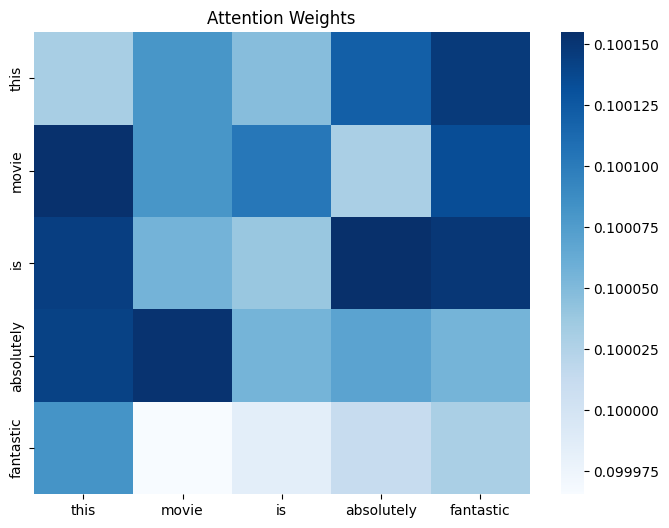

In [ ]:
# 8. Visualizing attention weights
def plot_attention_weights(attention_weights, text, tokenizer): # Removed layer parameter as it's not needed
    tokens = tokenizer.sequences_to_texts([text])[0].split()
    # Corrected indexing and slicing
    # Select the first item in the batch and average across the heads
    attention_mean_heads = attention_weights[0].mean(axis=0) # Shape: (seq_len, seq_len)
    # Slice to the actual length of the tokens
    attention = attention_mean_heads[:len(tokens), :len(tokens)] # Shape: (len(tokens), len(tokens))

    plt.figure(figsize=(8, 6))
    sns.heatmap(attention, xticklabels=tokens, yticklabels=tokens, cmap='Blues')
    plt.title("Attention Weights")
    plt.show()

    # Example visualization for the first test sample
test_text = sequences[0]
# Pad the test_text to the max_len before passing it to the attention_model
padded_test_text = pad_sequences([test_text], maxlen=max_len, padding='post', truncating='post')
attention_weights = attention_model.predict(padded_test_text)
plot_attention_weights(attention_weights, test_text, tokenizer) # Removed layer argument

In [ ]:
# 9. Making predictions
new_texts = ["Awesome movie loved it", "Horrible waste of time"]
new_sequences = tokenizer.texts_to_sequences(new_texts)
new_padded = pad_sequences(new_sequences, maxlen=max_len, padding='post', truncating='post')
predictions = model.predict(new_padded) # Only one output from the training model

for text, pred in zip(new_texts, predictions):
    sentiment = "Positive" if pred > 0.5 else "Negative"
    print(f"Text: {text}\nPredicted sentiment: {sentiment} ({float(pred[0]):.4f})\n") # Explicitly convert to float

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Text: Awesome movie loved it
Predicted sentiment: Positive (0.6430)

Text: Horrible waste of time
Predicted sentiment: Positive (0.5123)

